In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

#### Read the csv file

In [2]:
df = pd.read_csv('./data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

### Dataset information
- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [4]:
# check the number of missing values
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [5]:
# sum of duplicated rows
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [8]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### insights

- From the above description about the dataset the mean of each features are in between 66 to 68.5
- All the standard deviation are in between 15.16 to 15.19
- The minimum math_score is 0 and reading is 17 and for writing is 10

In [9]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
print("Categories in gender column:", end= " ")
print(df['gender'].unique())

print("Categories in race_ethnicity column:", end= " ")
print(df['race_ethnicity'].unique())

print("Categories in parental_level_of_education column:", end= " ")
print(df['parental_level_of_education'].unique())

print("Categories in lunch column:", end= " ")
print(df['lunch'].unique())

print("Categories in test_preparation_course column:", end= " ")
print(df['test_preparation_course'].unique())

Categories in gender column: <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in race_ethnicity column: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in parental_level_of_education column: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in lunch column: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test_preparation_course column: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [11]:
#categorical and numerical features
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']

print("Number of categorical features: ", len(categorical_features),categorical_features)
print('Number of numerical features :',len(numerical_features),numerical_features)

Number of categorical features:  5 ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
Number of numerical features : 3 ['math_score', 'reading_score', 'writing_score']


#### Observations
- Number of categorical features:  5 ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
- Number of numerical features : 5 ['math_score', 'reading_score', 'writing_score', 'Total_Score', 'Average_Score']


#### Adding Total score and Average score columns


In [24]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Score,Average_Score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333,229,76.333333


In [25]:
reading_full = (df["reading_score"] == 100).sum()
writing_full = (df["writing_score"] == 100).sum()
math_full = (df["math_score"] == 100).sum()

print("Number of full marks in reading: ", reading_full)
print("Number of full marks in writing: ", writing_full)
print("Number of full marks in math: ", math_full)

Number of full marks in reading:  17
Number of full marks in writing:  14
Number of full marks in math:  7


In [26]:
writing_less_20 = (df["writing_score"] < 20).sum()
reading_less_20 = (df["reading_score"] < 20).sum()
math_less_20 = (df["math_score"] < 20).sum()

print("Number of scores less than 20 in writing: ", writing_less_20)
print("Number of scores less than 20 in reading: ", reading_less_20)
print("Number of scores less than 20 in math: ", math_less_20)

Number of scores less than 20 in writing:  3
Number of scores less than 20 in reading:  1
Number of scores less than 20 in math:  4


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### Exploring Data ( Visualization )
#### Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

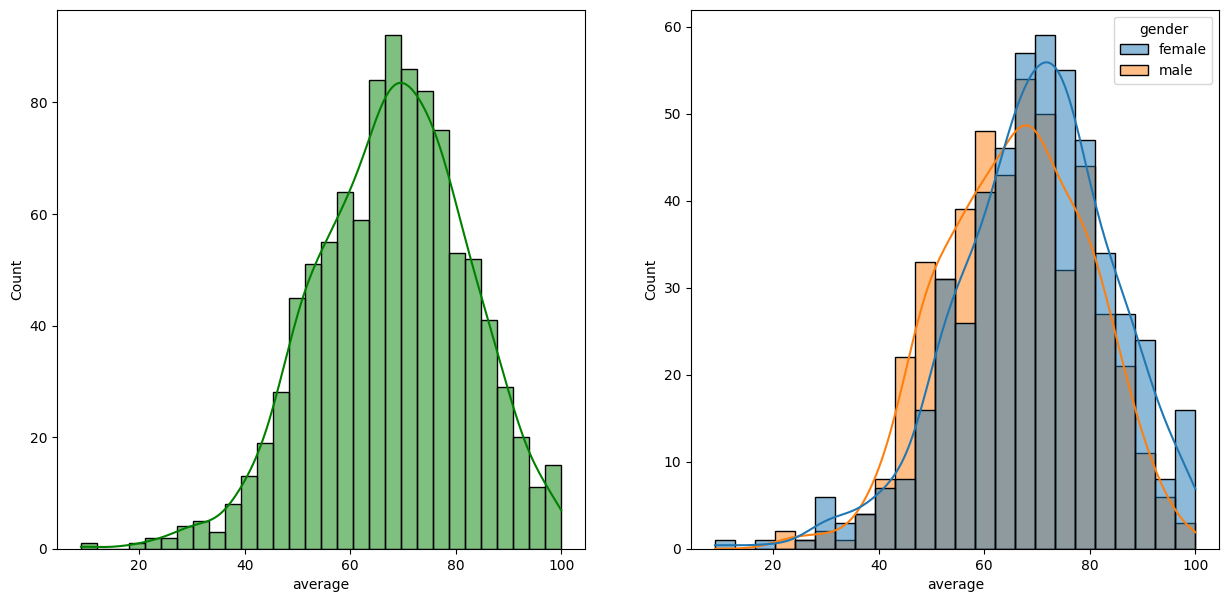

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x="average", bins=30, kde=True, color="g")
plt.subplot(122)
sns.histplot(data=df, x="average", kde=True, hue="gender")
plt.show()

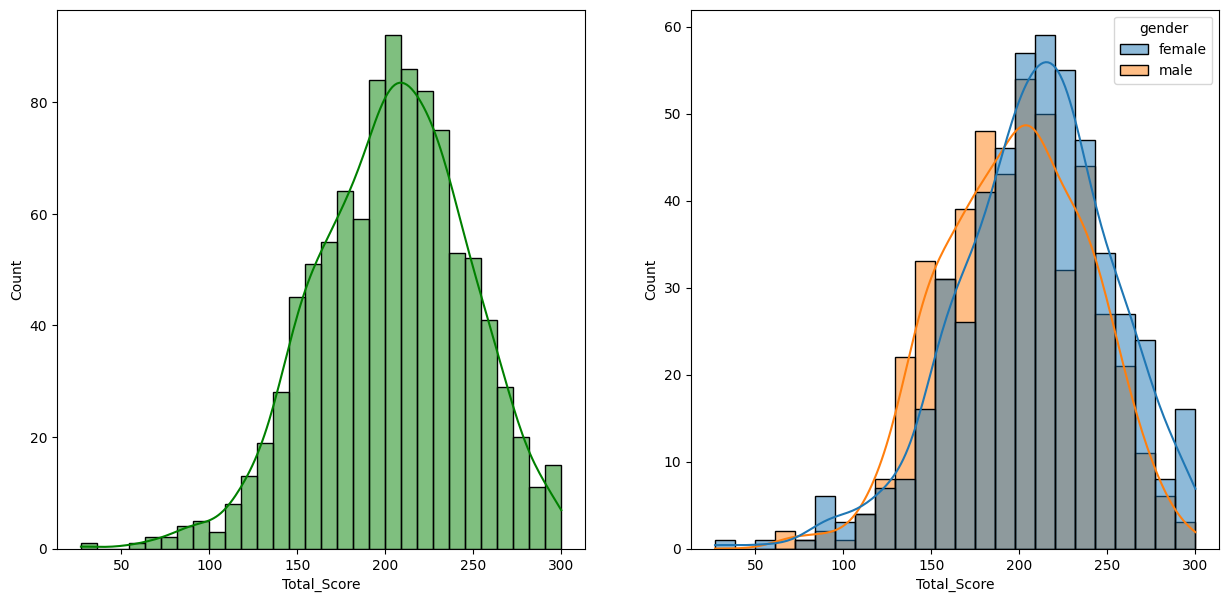

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x="Total_Score", bins=30, kde=True, color="g")
plt.subplot(122)
sns.histplot(data=df, x="Total_Score", kde=True, hue="gender")
plt.show()

### insights
- female students tend to perform well then male students.

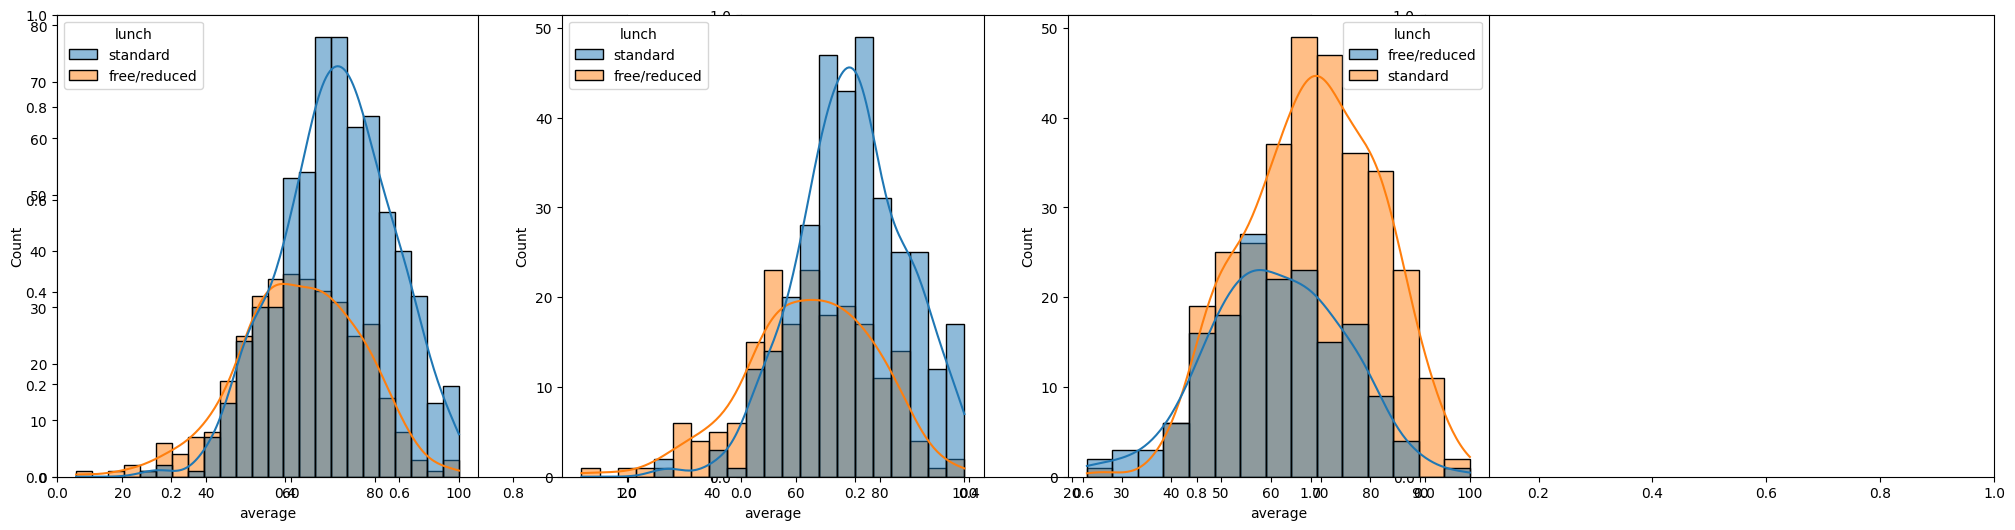

In [28]:
plt.subplots(1, 3, figsize=(25, 6))
plt.subplot(141)
sns.histplot(data=df, x="average", kde=True, hue="lunch")
plt.subplot(142)
sns.histplot(data=df[df.gender == "female"], x="average", kde=True, hue="lunch")
plt.subplot(143)
sns.histplot(data=df[df.gender == "male"], x="average", kde=True, hue="lunch")
plt.show()

### insights
- standard lunch helps perform well in exams
- standard lunch helps both male and female in exams

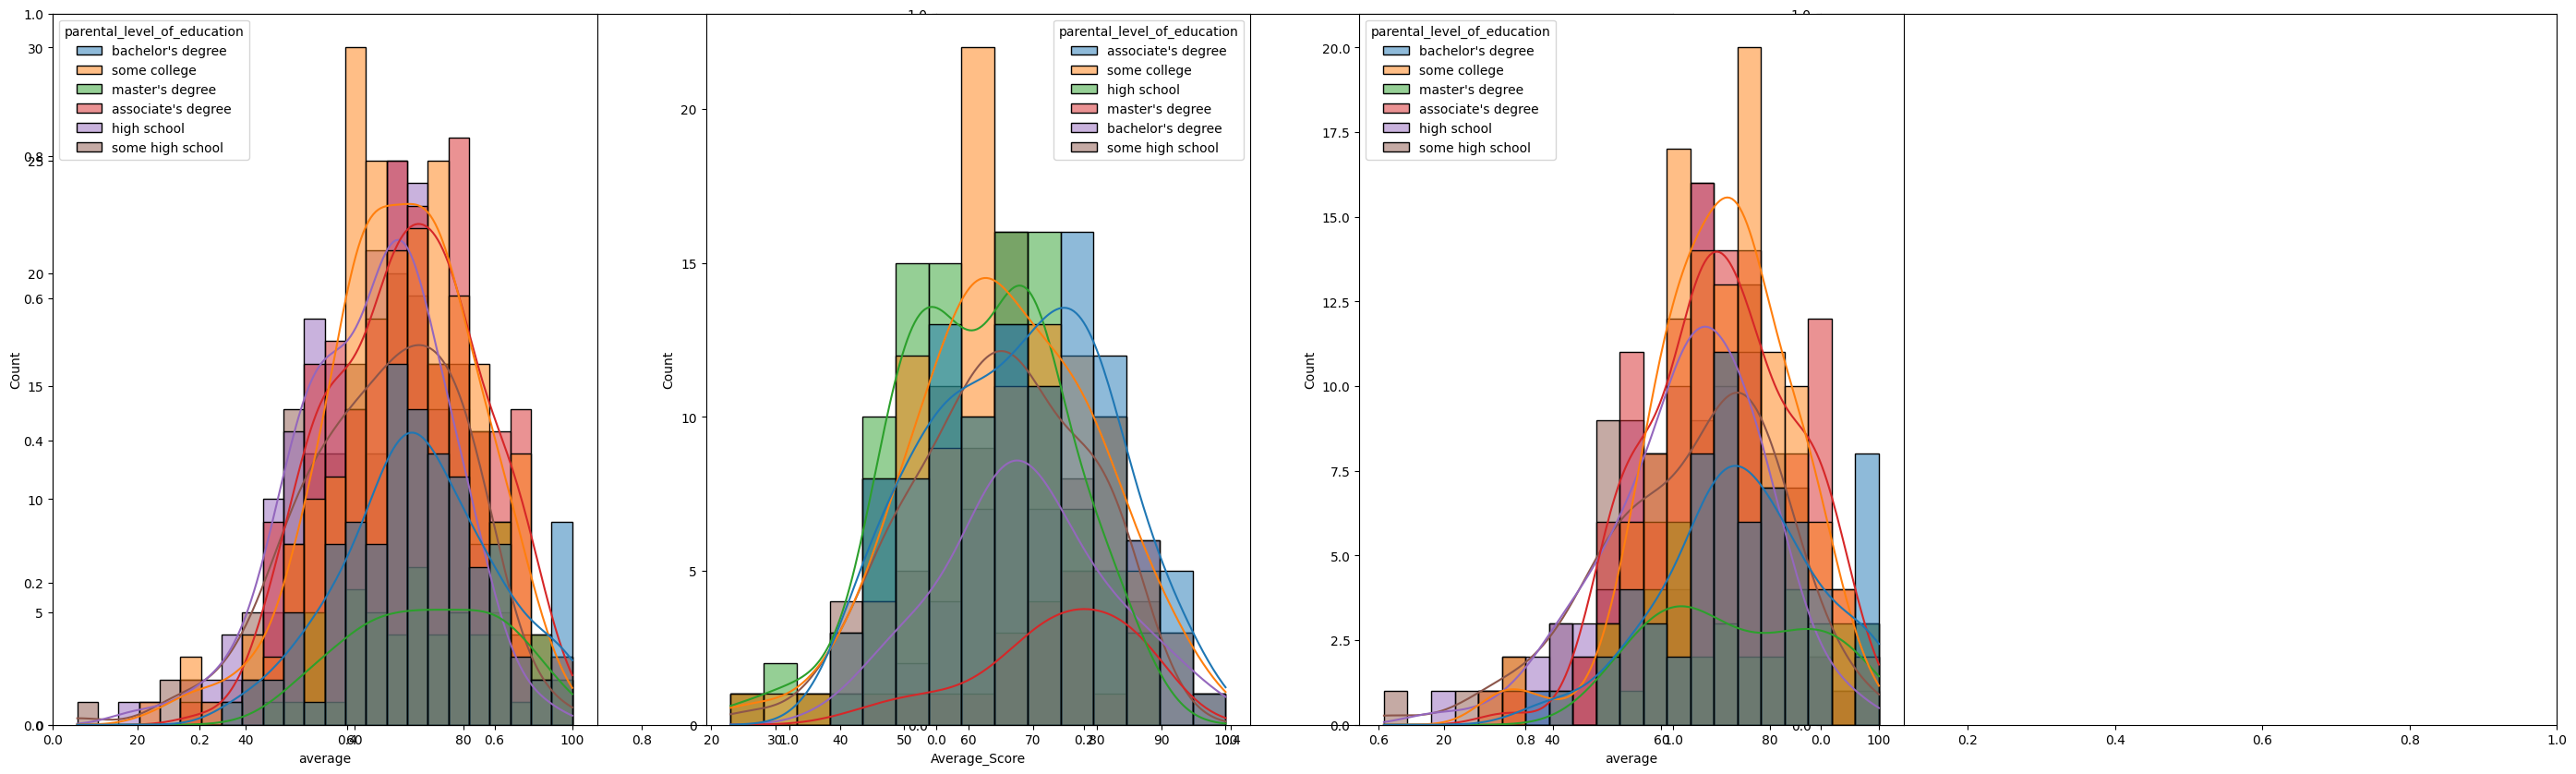

In [29]:
plt.subplots(1,3,figsize=(35,10))
plt.subplot(141)
sx = sns.histplot(data=df, x="average", kde=True, hue="parental_level_of_education")
plt.subplot(142)
ax = sns.histplot(
    data=df[df.gender == "male"],
    x="Average_Score",
    kde=True,
    hue="parental_level_of_education",
)
plt.subplot(143)
ax = sns.histplot(
    data=df[df.gender == "female"],
    x="average",
    kde=True,
    hue="parental_level_of_education",
)
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.

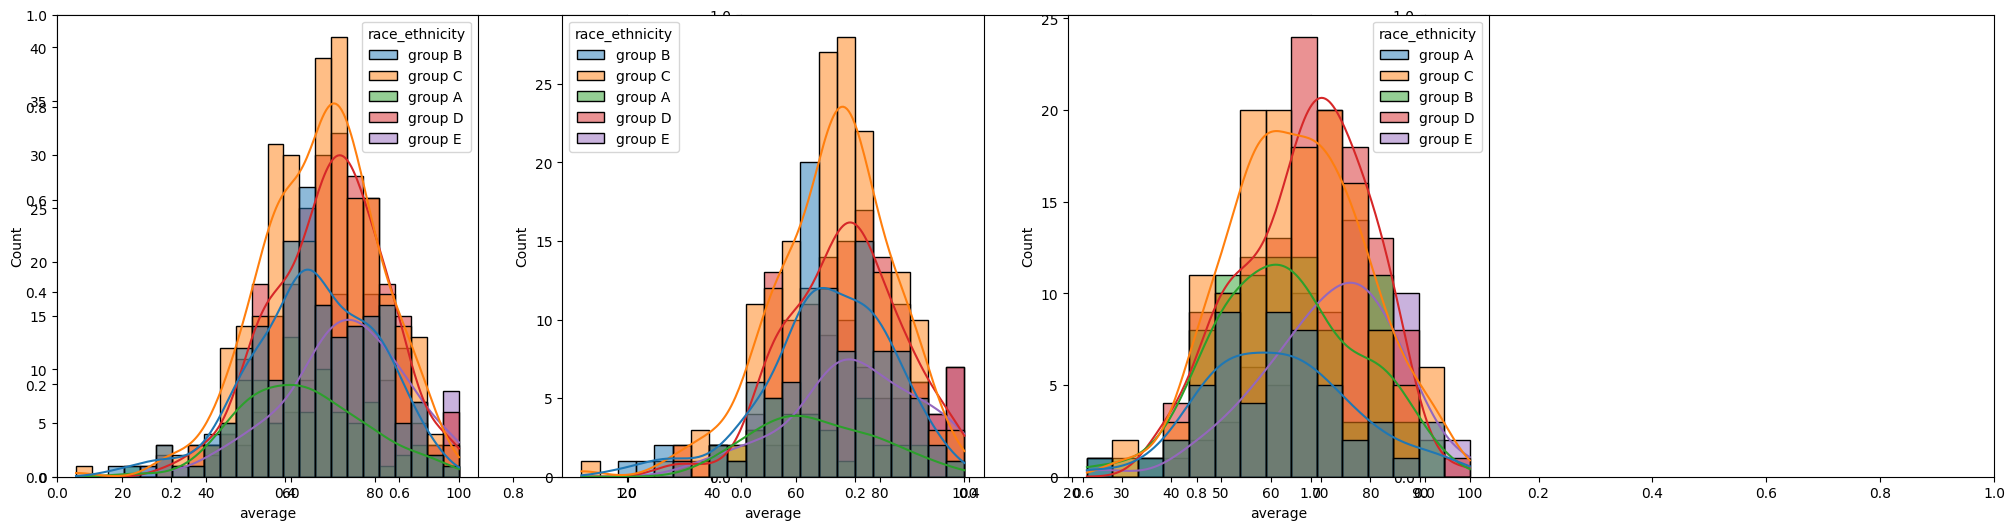

In [30]:
plt.subplots(1, 3, figsize=(25, 6))
plt.subplot(141)
ax = sns.histplot(data=df, x="average", kde=True, hue="race_ethnicity")
plt.subplot(142)
ax = sns.histplot(
    data=df[df.gender == "female"], x="average", kde=True, hue="race_ethnicity"
)
plt.subplot(143)
ax = sns.histplot(
    data=df[df.gender == "male"], x="average", kde=True, hue="race_ethnicity"
)
plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

<Axes: xlabel='average', ylabel='Count'>

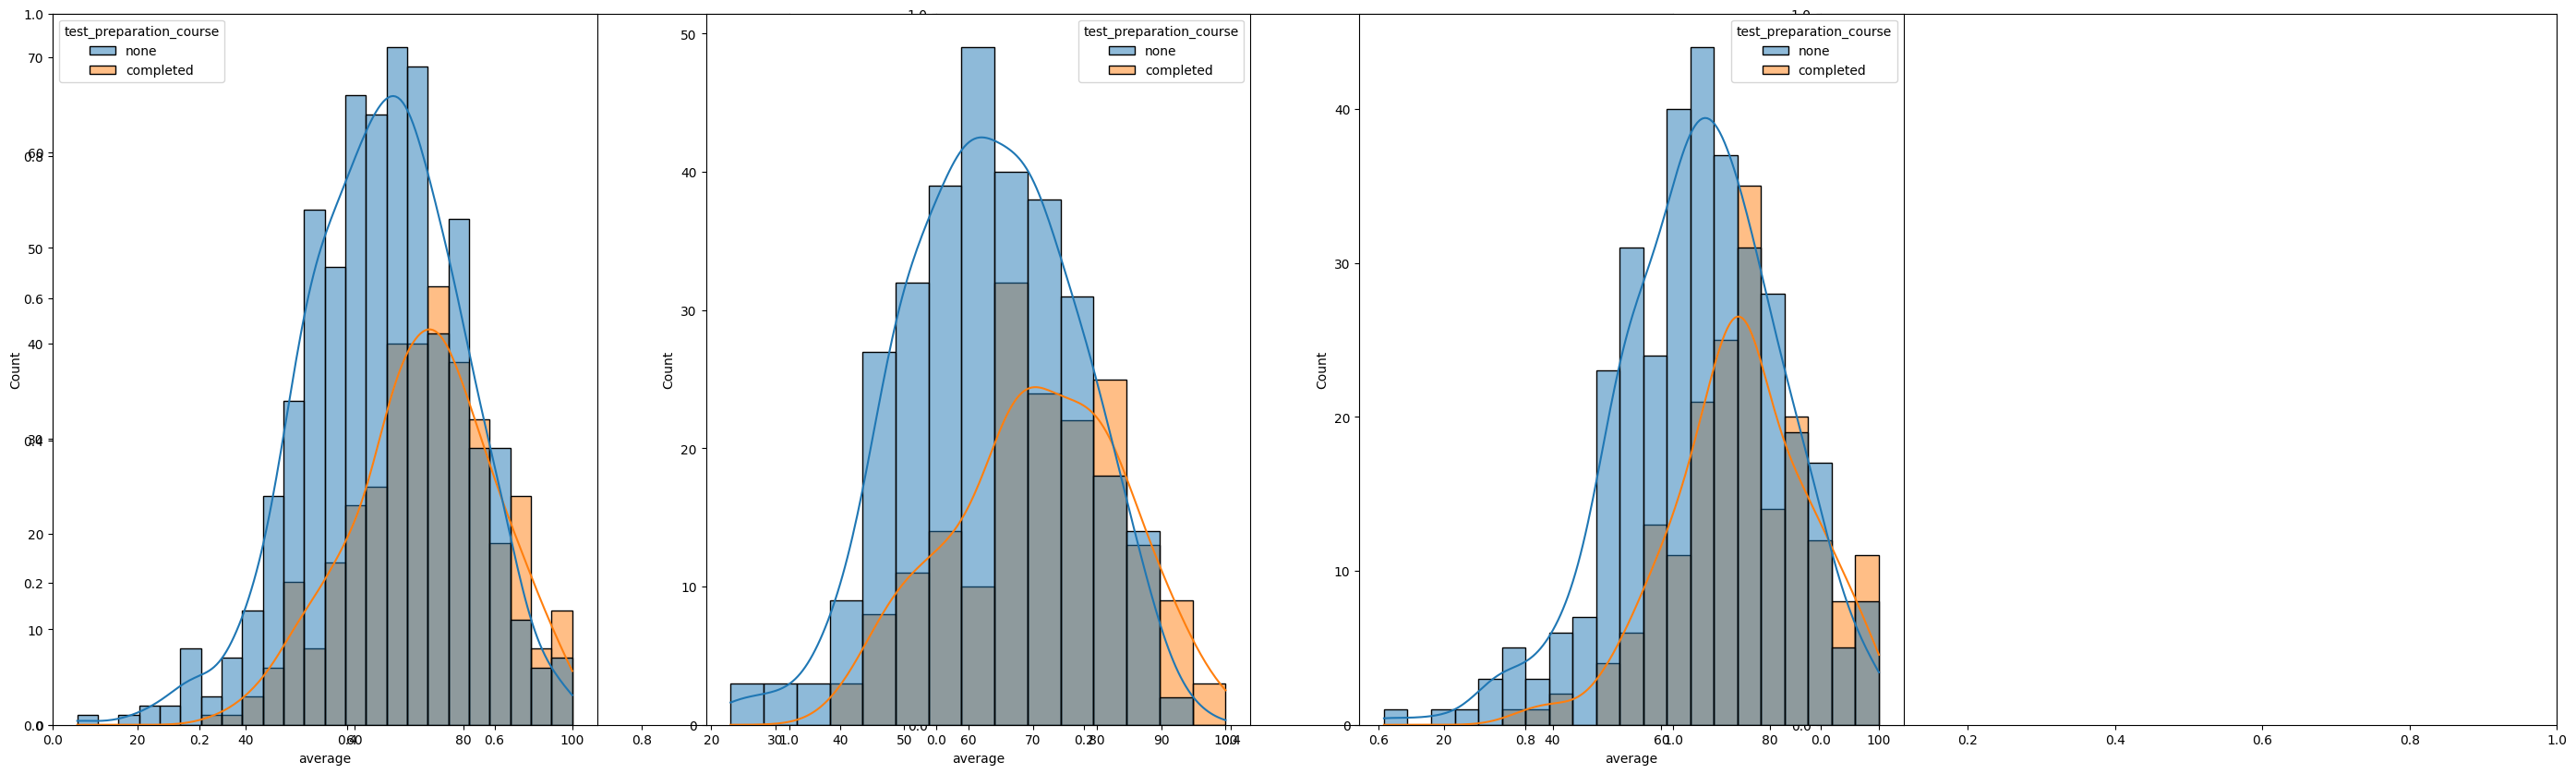

In [31]:
plt.subplots(1,3,figsize = (35,10))
plt.subplot(141)
sns.histplot(data=df, x="average", hue="test_preparation_course", kde=True)
plt.subplot(142)
sns.histplot(
    data=df[df.gender == "male"], x="average", hue="test_preparation_course", kde=True
)
plt.subplot(143)
sns.histplot(
    data=df[df.gender == "female"],
    x="average",
    hue="test_preparation_course",
    kde=True,
)

#### insights
- Student's Performance is not much related with test preparation course based on gender

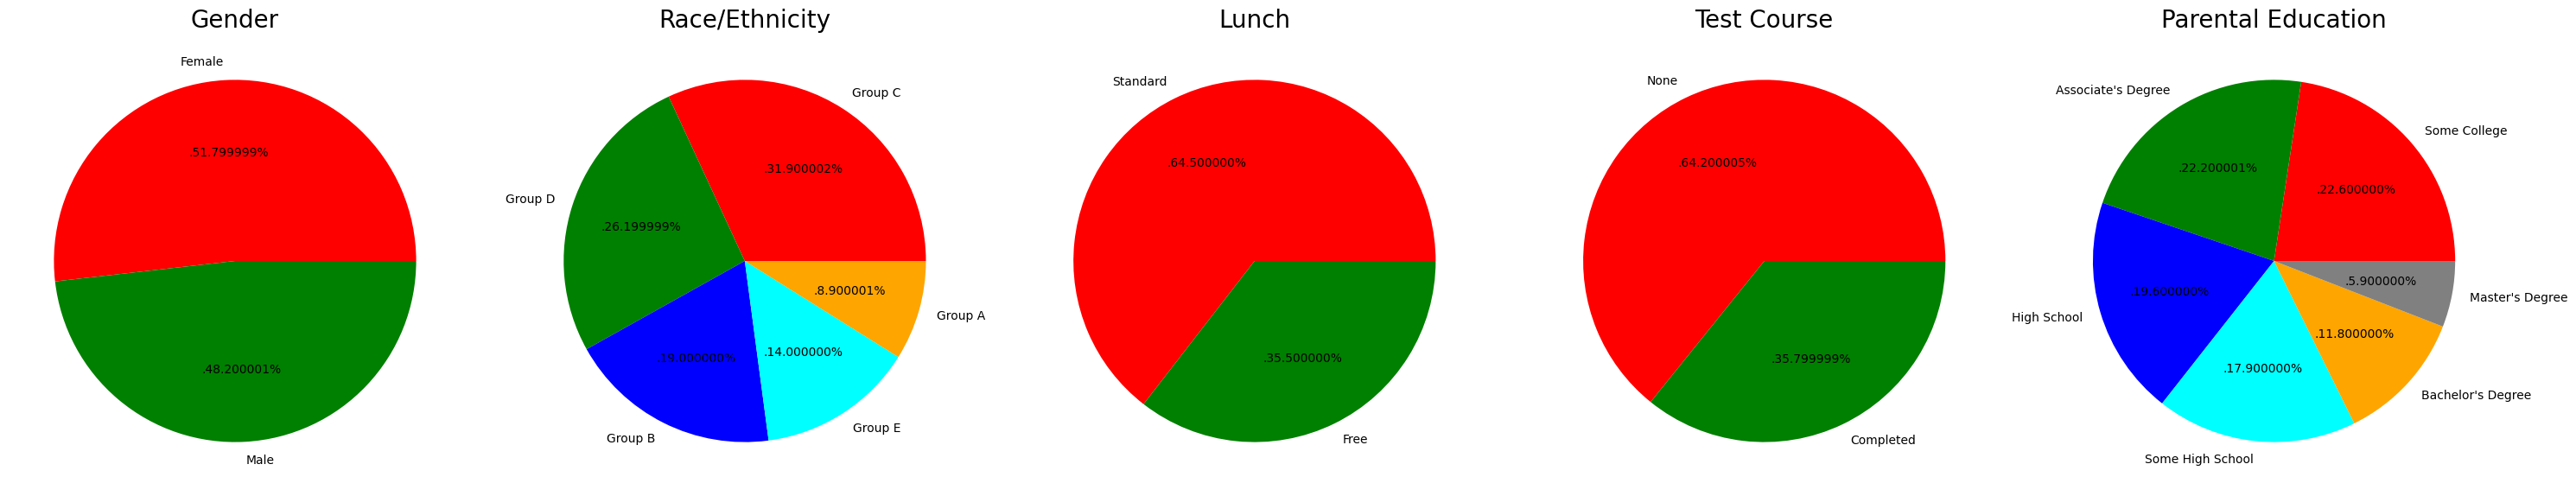

In [32]:
plt.rcParams["figure.figsize"] = (30, 12)

plt.subplot(1, 5, 1)
size = df["gender"].value_counts()
labels = "Female", "Male"
color = ["red", "green"]


plt.pie(size, colors=color, labels=labels, autopct=".%2f%%")
plt.title("Gender", fontsize=20)
plt.axis("off")


plt.subplot(1, 5, 2)
size = df["race_ethnicity"].value_counts()
labels = "Group C", "Group D", "Group B", "Group E", "Group A"
color = ["red", "green", "blue", "cyan", "orange"]

plt.pie(size, colors=color, labels=labels, autopct=".%2f%%")
plt.title("Race/Ethnicity", fontsize=20)
plt.axis("off")


plt.subplot(1, 5, 3)
size = df["lunch"].value_counts()
labels = "Standard", "Free"
color = ["red", "green"]

plt.pie(size, colors=color, labels=labels, autopct=".%2f%%")
plt.title("Lunch", fontsize=20)
plt.axis("off")


plt.subplot(1, 5, 4)
size = df["test_preparation_course"].value_counts()
labels = "None", "Completed"
color = ["red", "green"]

plt.pie(size, colors=color, labels=labels, autopct=".%2f%%")
plt.title("Test Course", fontsize=20)
plt.axis("off")


plt.subplot(1, 5, 5)
size = df["parental_level_of_education"].value_counts()
labels = (
    "Some College",
    "Associate's Degree",
    "High School",
    "Some High School",
    "Bachelor's Degree",
    "Master's Degree",
)
color = ["red", "green", "blue", "cyan", "orange", "grey"]

plt.pie(size, colors=color, labels=labels, autopct=".%2f%%")
plt.title("Parental Education", fontsize=20)
plt.axis("off")


plt.tight_layout()
plt.grid()

#### Insights

  - Number of Male and Female students is almost equal
  - Number students are greatest in Group C
  - Number of students who have standard lunch are greater
  - Number of students who have not enrolled in any test preparation course is greater
  - Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"


### Feature wise Visualization
#### Gender column
 - How is the distribution of gender?
 - does the gender has any impact on student's performance

([<matplotlib.patches.Wedge at 0x78244d8c5950>,
 [Text(-0.06782234990611144, 1.1980818539871194, 'Female'),
  Text(0.06782216900078375, -1.1980818642279956, 'Male')],
 [Text(-0.03956303744523167, 0.6988810814924862, '51.80%'),
  Text(0.039562931917123845, -0.6988810874663307, '48.20%')])

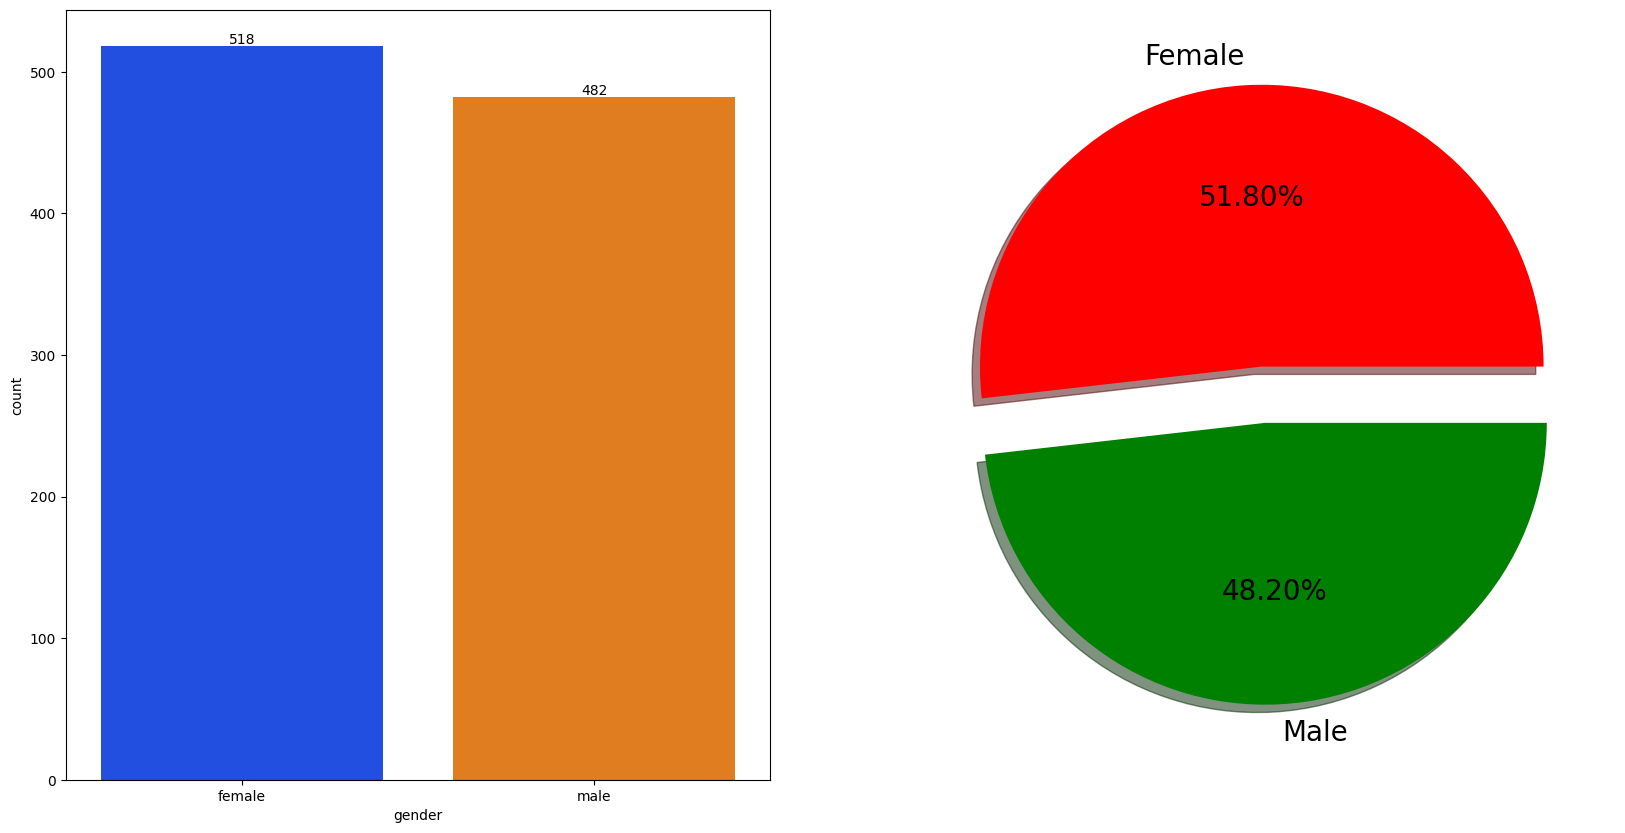

In [33]:
f,ax = plt.subplots(1,2,figsize = (20,10))
sns.countplot(data=df,x=df['gender'],palette='bright',ax=ax[0])
for container in ax[0].containers:
  ax[0].bar_label(container)

plt.subplot(122)
plt.pie(df['gender'].value_counts(),labels=['Female','Male'],autopct='%.2f%%',explode=[0.1,0.1],colors=['red','green'],textprops={'fontsize':20},shadow=True)

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

In [41]:
gender_group = df.groupby("gender")[["average", "math_score"]].mean()
print(gender_group)

          average  math_score
gender                       
female  69.569498   63.633205
male    65.837483   68.728216


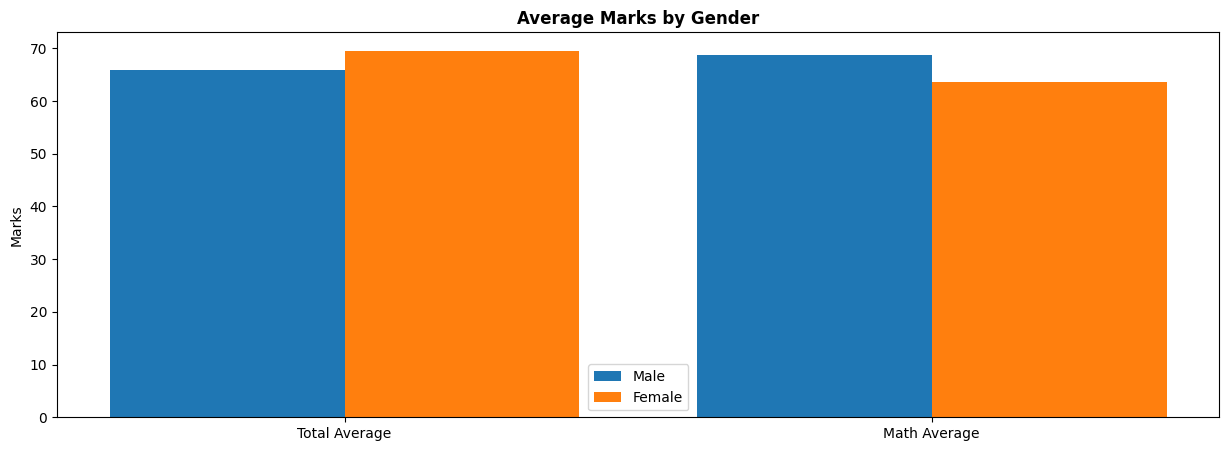

In [47]:
plt.figure(figsize=(15, 5))

X = ["Total Average", "Math Average"]

female_scores = [
    gender_group.loc["female", "average"],
    gender_group.loc["female", "math_score"],
]

male_scores = [
    gender_group.loc["male", "average"],
    gender_group.loc["male", "math_score"],
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label="Male")
plt.bar(X_axis + 0.2, female_scores, 0.4, label="Female")

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Average Marks by Gender", fontweight="bold")
plt.legend()

plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

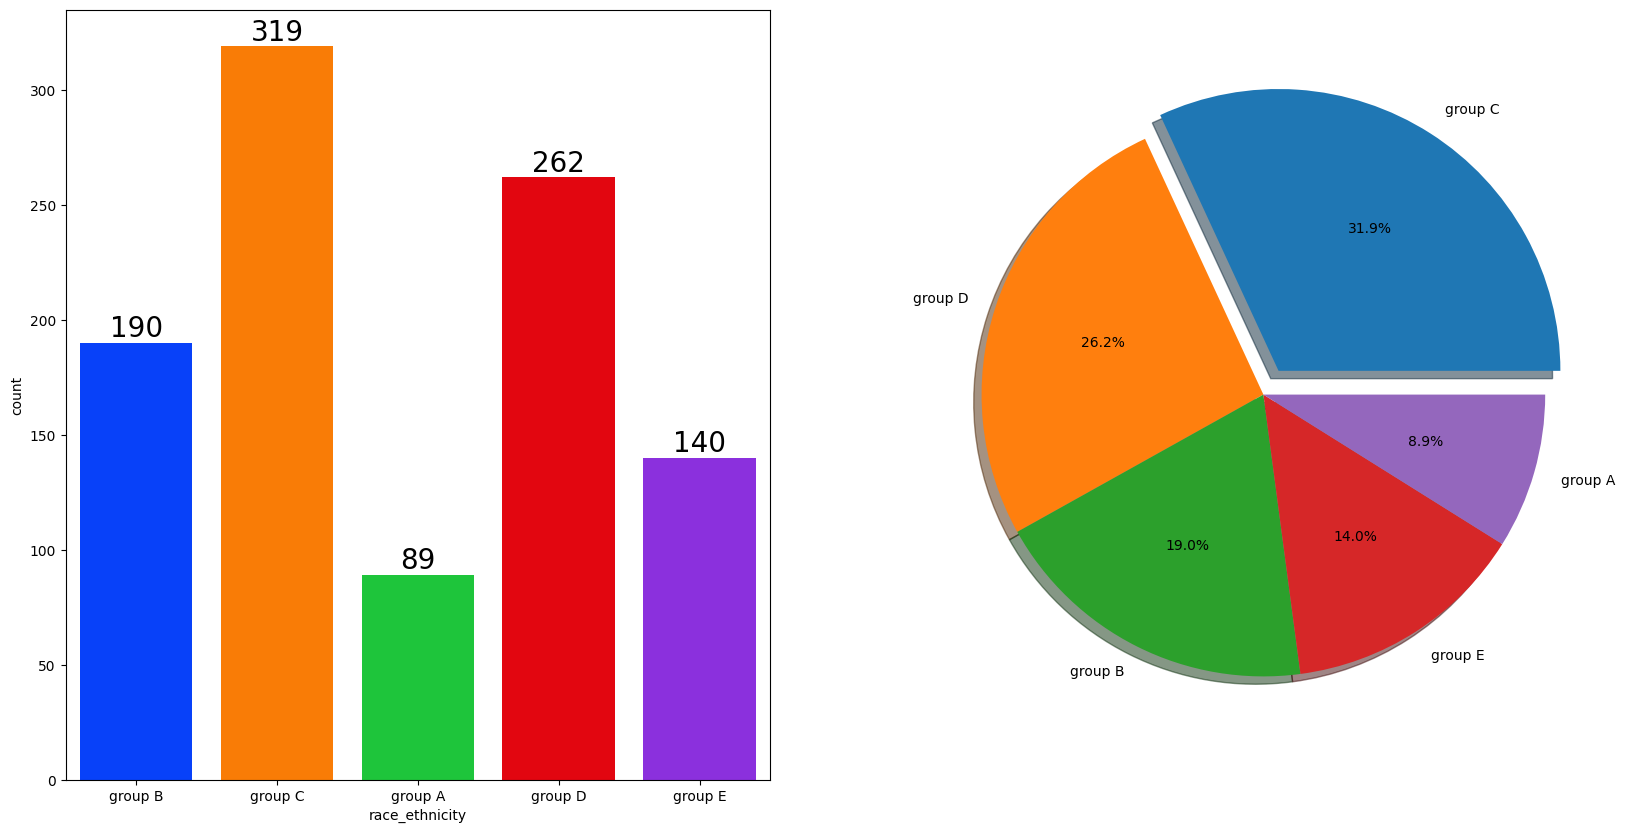

In [49]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.countplot(
    x=df["race_ethnicity"], data=df, palette="bright", ax=ax[0], saturation=0.95
)
for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=20)

plt.pie(
    x=df["race_ethnicity"].value_counts(),
    labels=df["race_ethnicity"].value_counts().index,
    explode=[0.1, 0, 0, 0, 0],
    autopct="%1.1f%%",
    shadow=True,
)
plt.show()

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

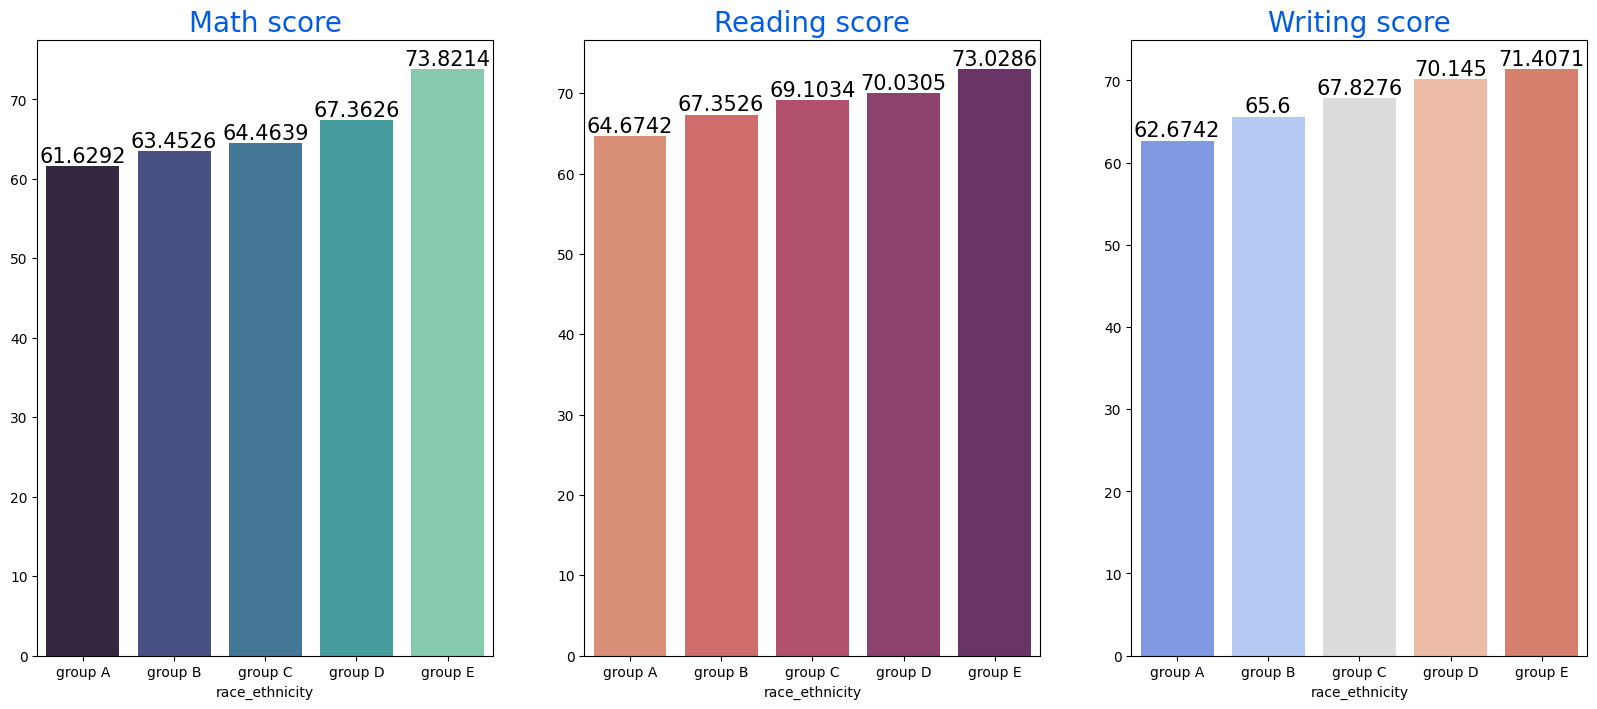

In [50]:
Group_data2 = df.groupby("race_ethnicity")
f, ax = plt.subplots(1, 3, figsize=(20, 8))
sns.barplot(
    x=Group_data2["math_score"].mean().index,
    y=Group_data2["math_score"].mean().values,
    palette="mako",
    ax=ax[0],
)
ax[0].set_title("Math score", color="#005ce6", size=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=15)

sns.barplot(
    x=Group_data2["reading_score"].mean().index,
    y=Group_data2["reading_score"].mean().values,
    palette="flare",
    ax=ax[1],
)
ax[1].set_title("Reading score", color="#005ce6", size=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color="black", size=15)

sns.barplot(
    x=Group_data2["writing_score"].mean().index,
    y=Group_data2["writing_score"].mean().values,
    palette="coolwarm",
    ax=ax[2],
)
ax[2].set_title("Writing score", color="#005ce6", size=20)

for container in ax[2].containers:
    ax[2].bar_label(container, color="black", size=15)

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

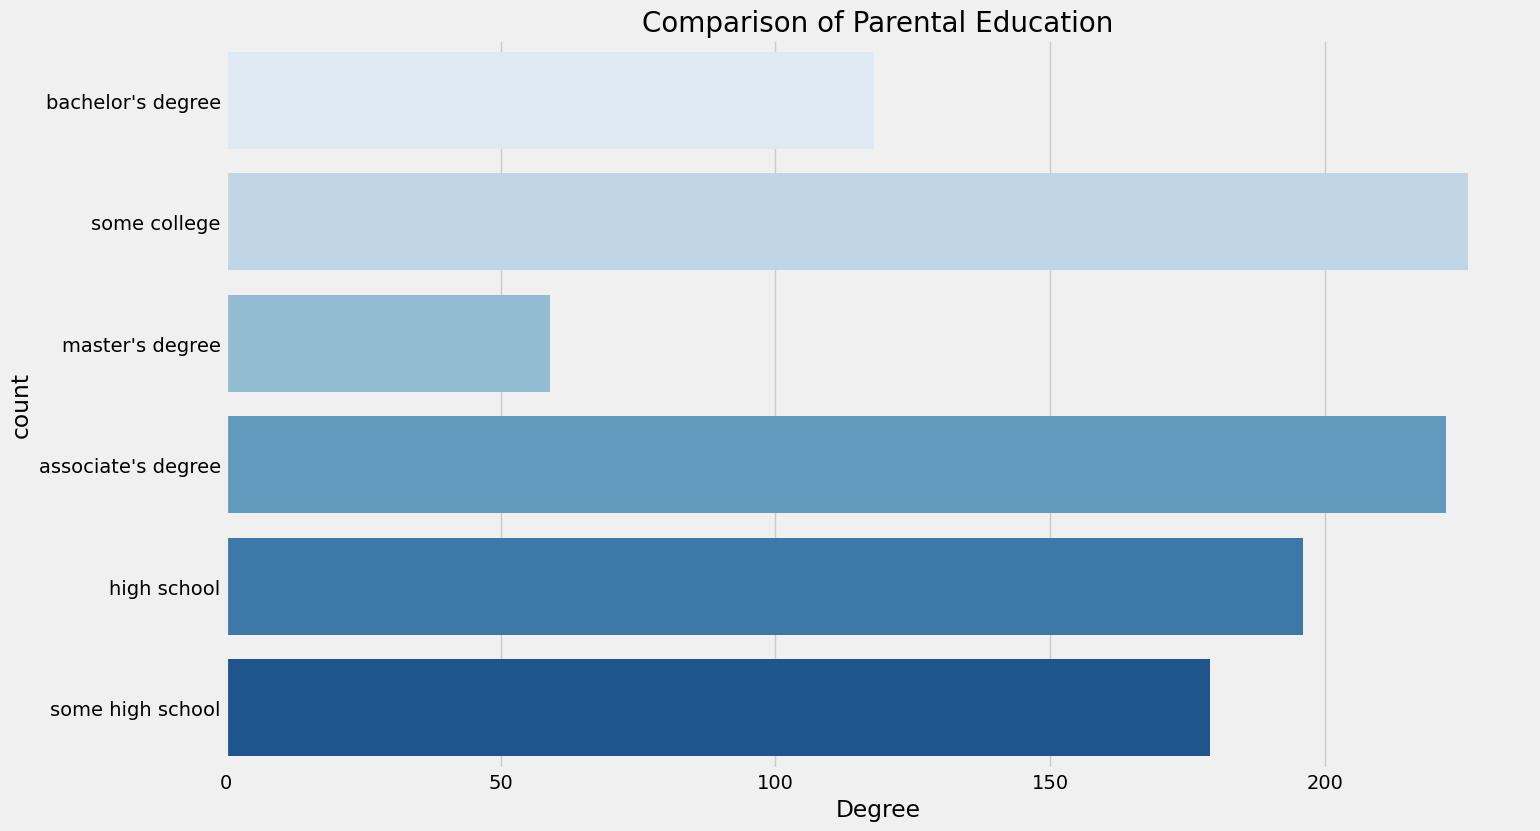

In [52]:
plt.rcParams["figure.figsize"] = (15, 9)
plt.style.use("fivethirtyeight")
sns.countplot(df["parental_level_of_education"], palette="Blues")
plt.title("Comparison of Parental Education", fontweight=30, fontsize=20)
plt.xlabel("Degree")
plt.ylabel("count")
plt.show()

#### Insights 
- Largest number of parents are from some colleg

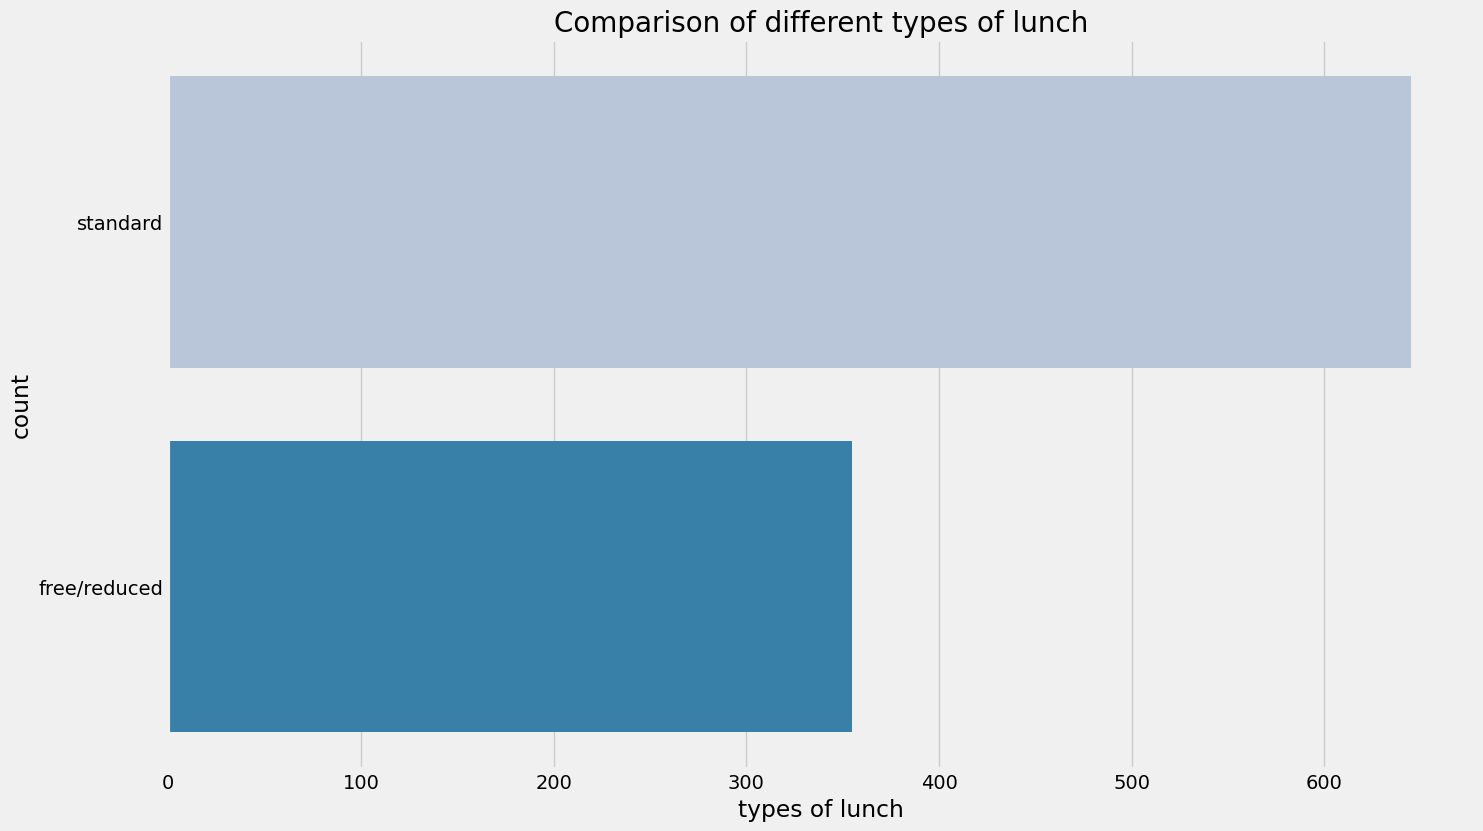

In [57]:
plt.rcParams["figure.figsize"] = (15, 9)
sns.countplot(df["lunch"], palette="PuBu")
plt.title("Comparison of different types of lunch", fontweight=30, fontsize=20)
plt.xlabel("types of lunch")
plt.ylabel("count")
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

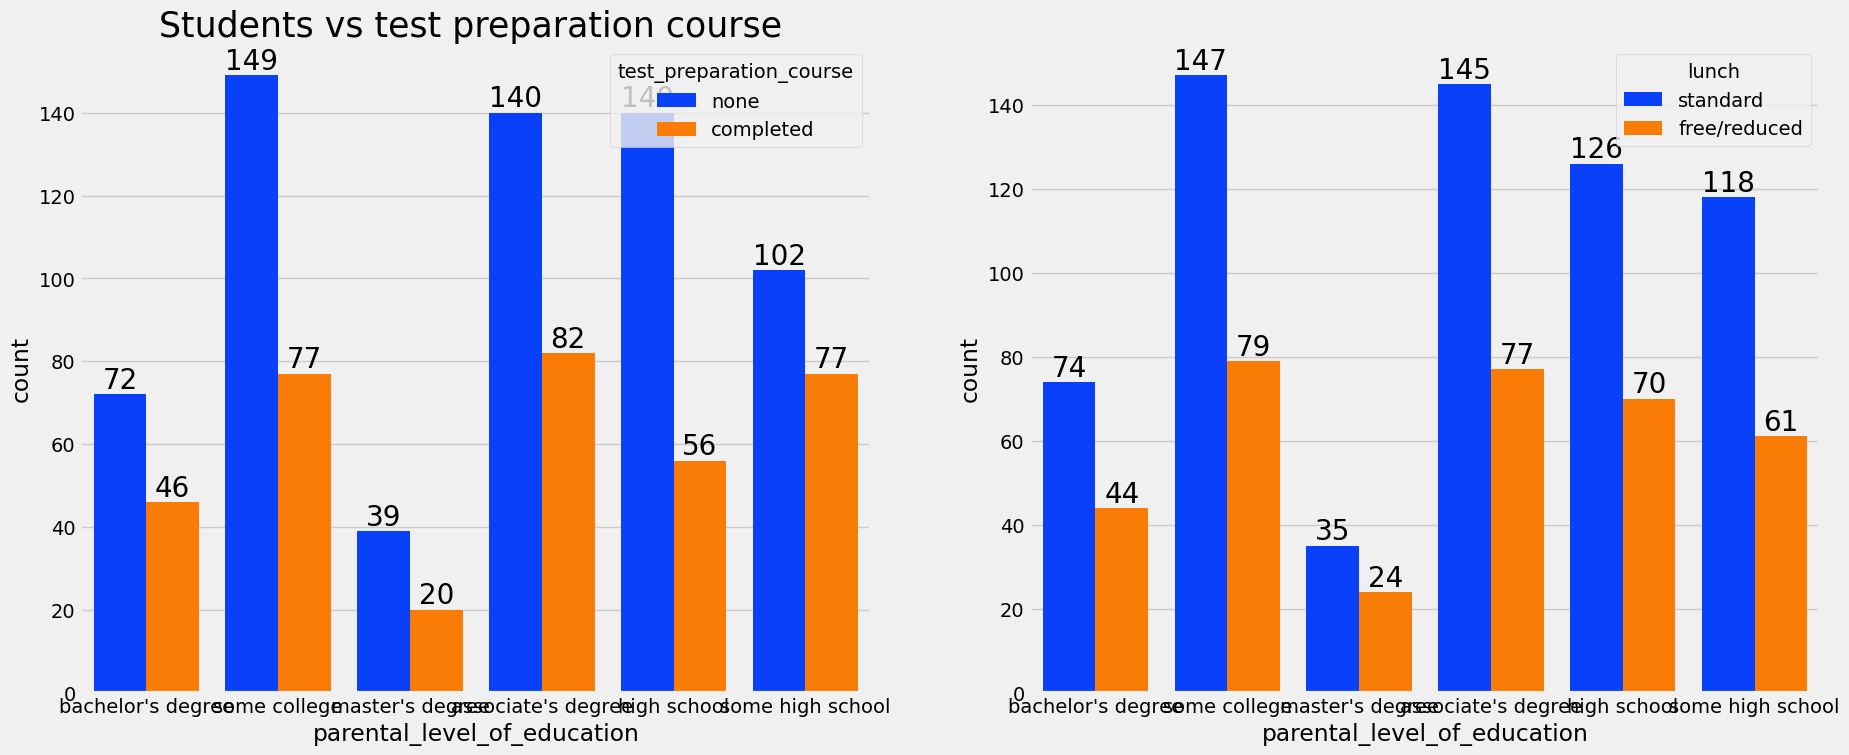

In [66]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

sns.countplot(
    x=df["parental_level_of_education"],
    data=df,
    palette="bright",
    hue="lunch",
    saturation=0.95,
    ax=ax[1],
)
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)

<Axes: xlabel='lunch', ylabel='writing_score'>

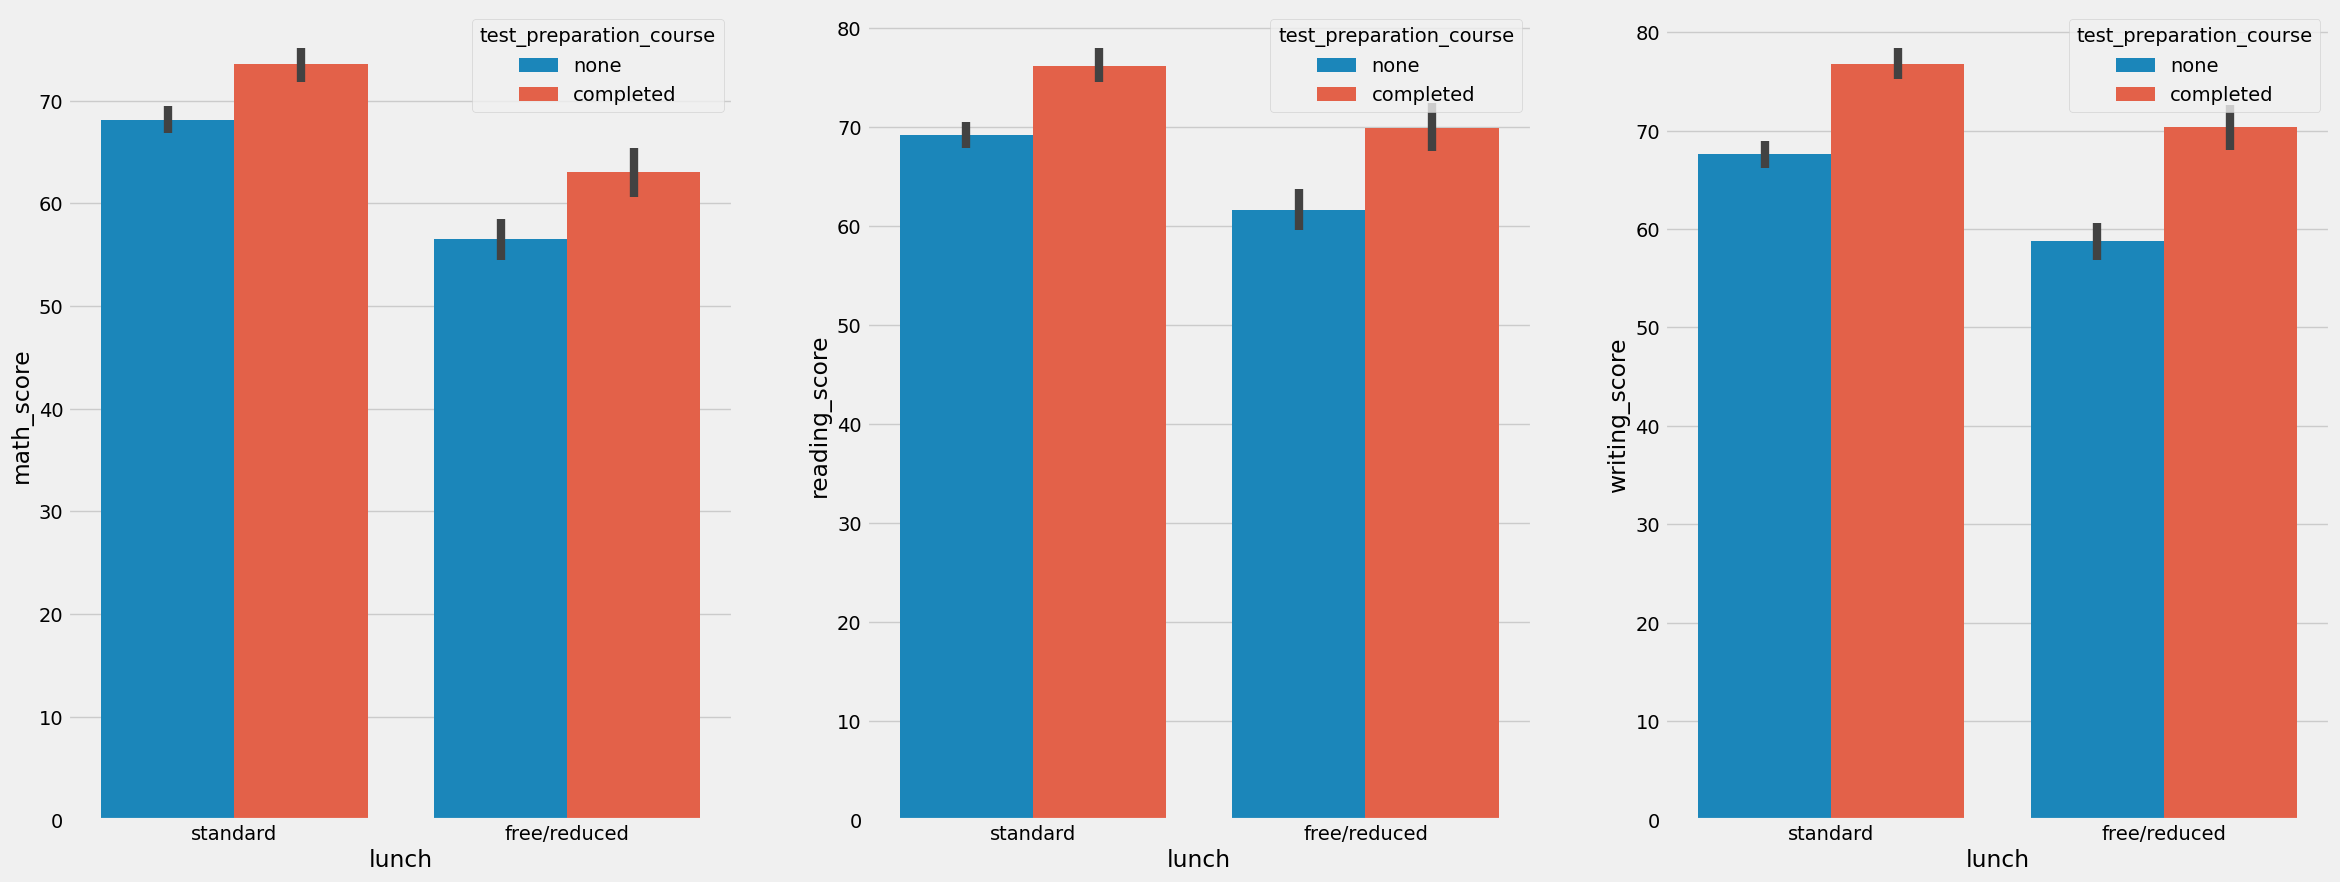

In [88]:
plt.subplots(1,3,figsize=(26,10))
plt.subplot(131)
sns.barplot(x=df["lunch"], y=df["math_score"], hue=df["test_preparation_course"])
plt.subplot(132)
sns.barplot(x=df["lunch"], y=df["reading_score"], hue=df["test_preparation_course"])
plt.subplot(133)
sns.barplot(x=df["lunch"], y=df["writing_score"], hue=df["test_preparation_course"])

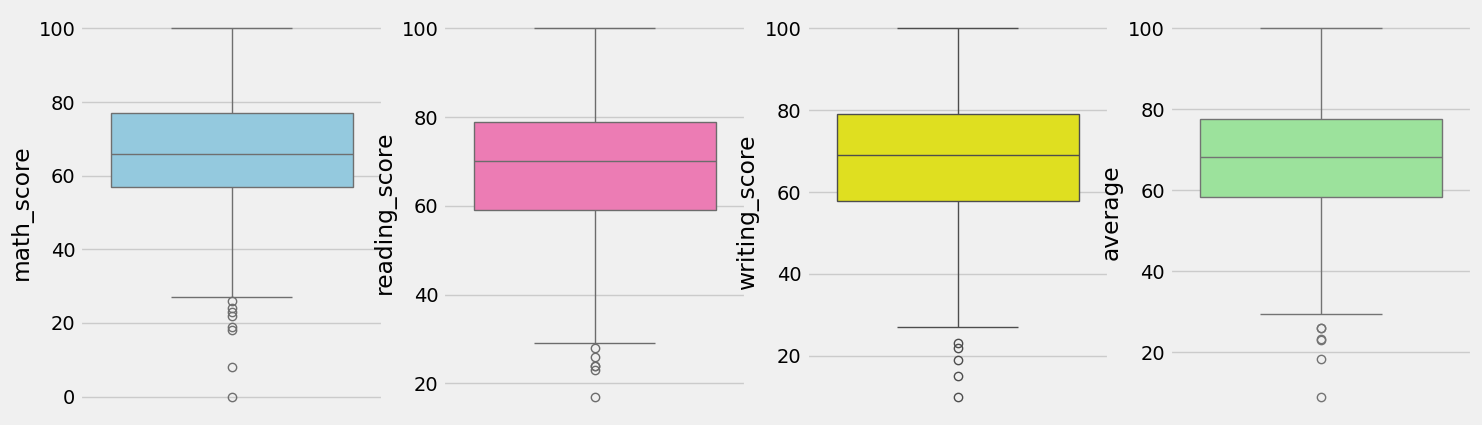

In [72]:
plt.subplots(1, 4, figsize=(16, 5))
plt.subplot(141)
sns.boxplot(df["math_score"], color="skyblue")
plt.subplot(142)
sns.boxplot(df["reading_score"], color="hotpink")
plt.subplot(143)
sns.boxplot(df["writing_score"], color="yellow")
plt.subplot(144)
sns.boxplot(df["average"], color="lightgreen")
plt.show()

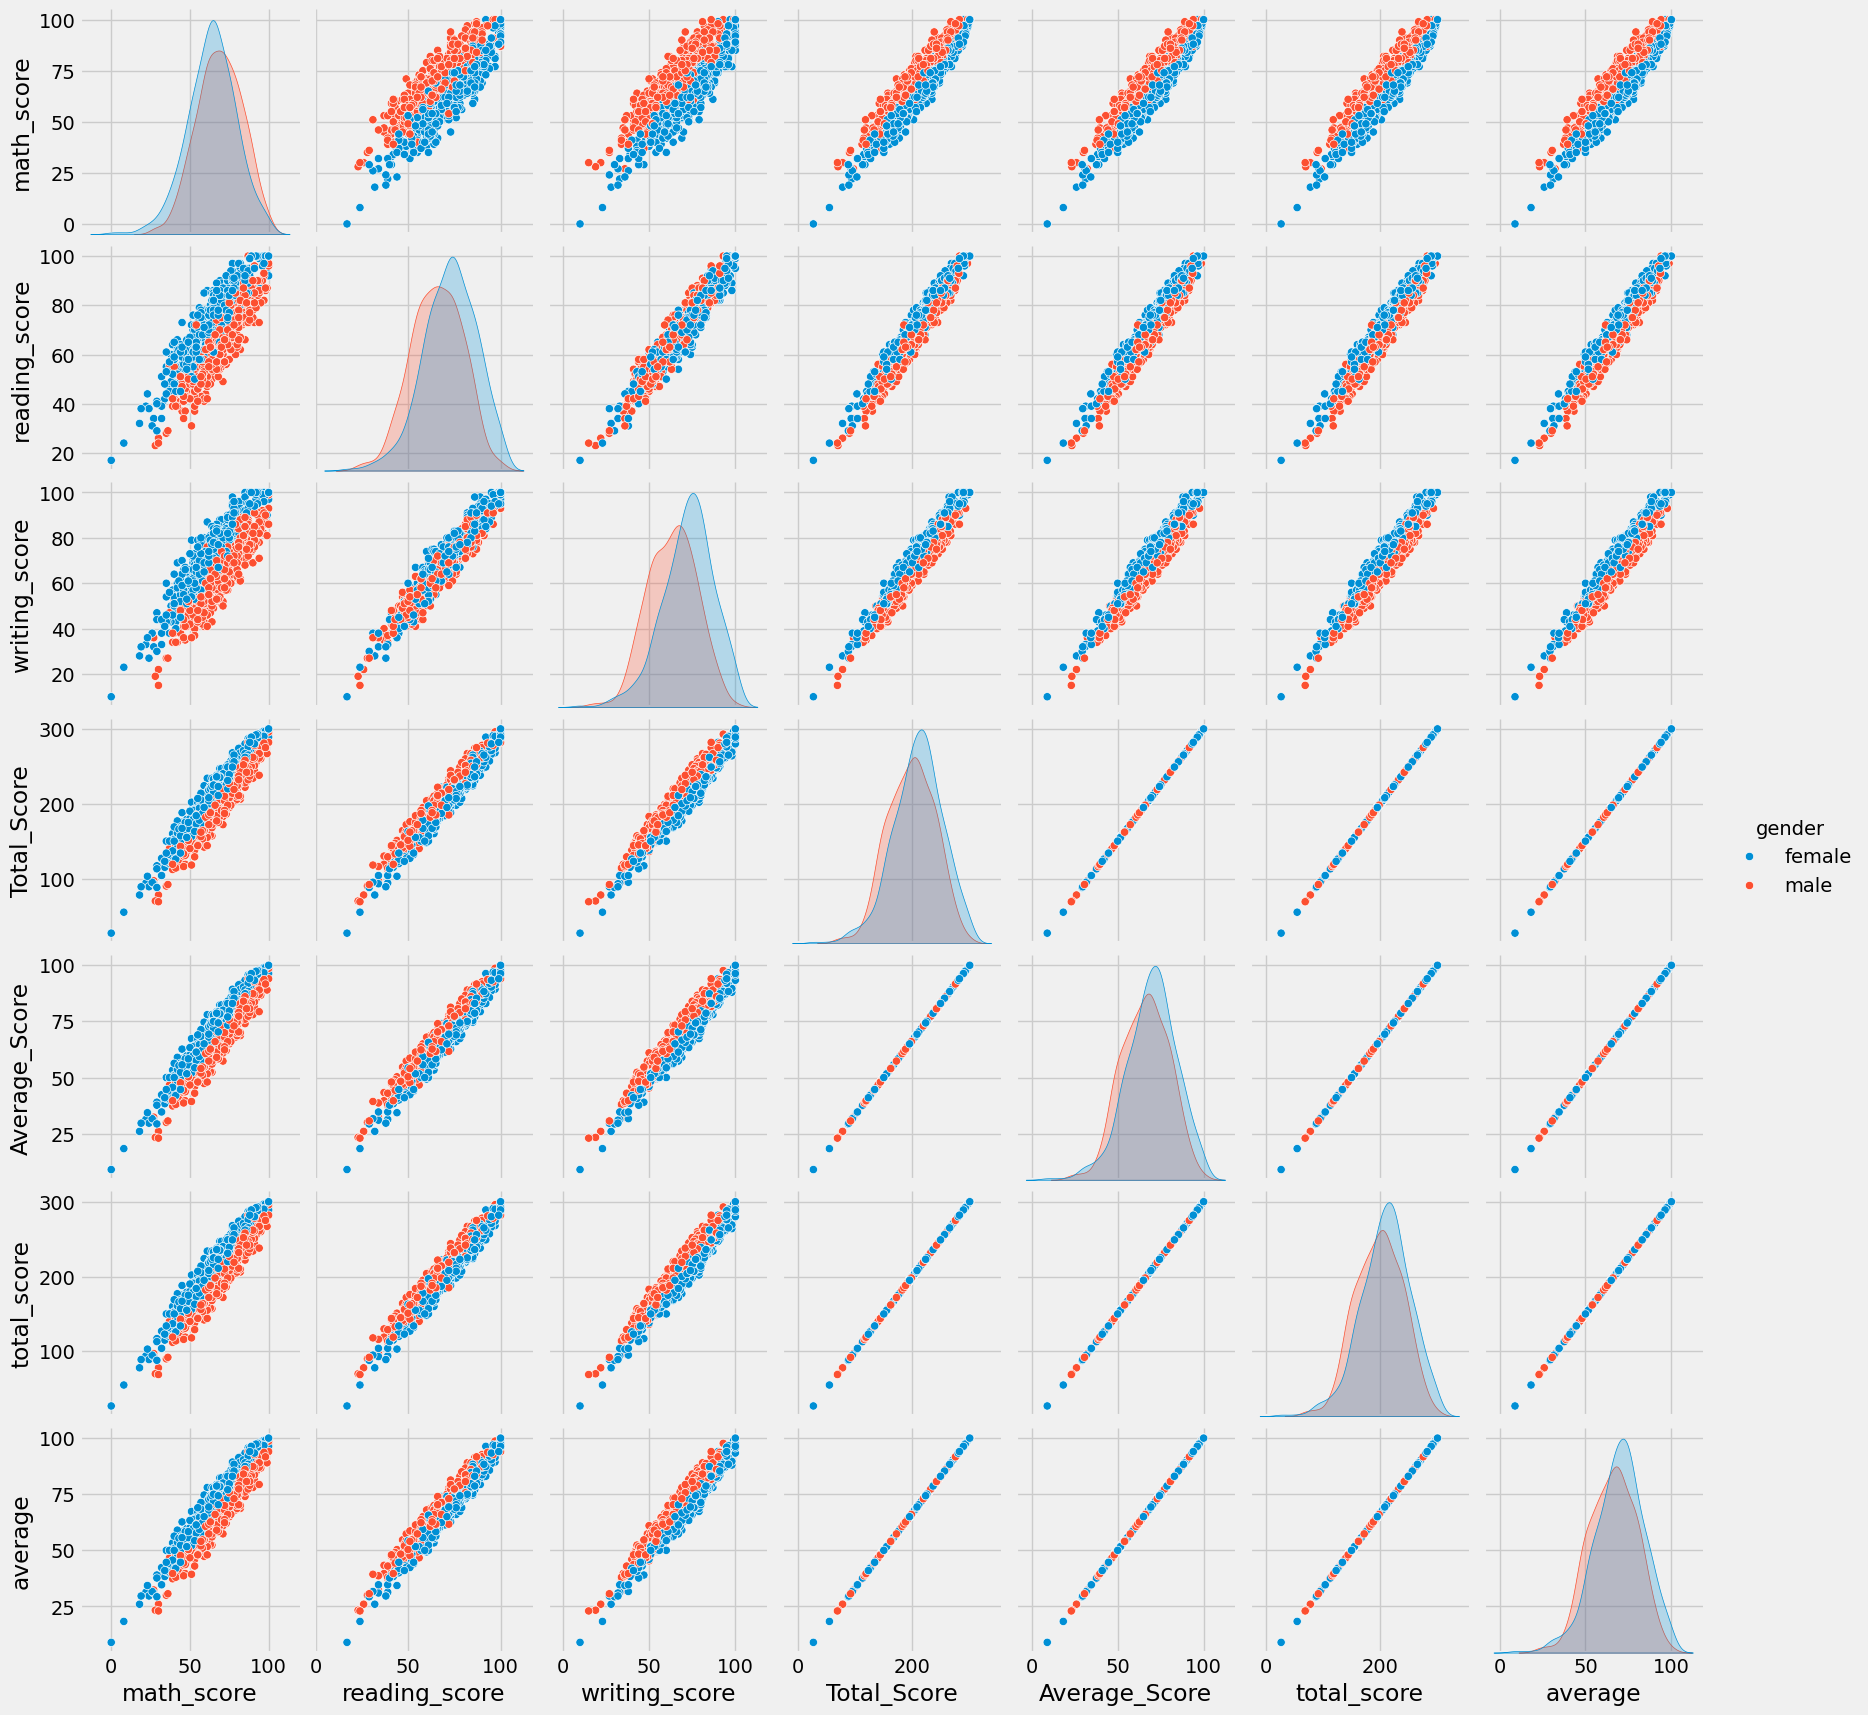

In [73]:
sns.pairplot(df, hue="gender")
plt.show()

### Insights

  - From the above plot it is clear that all the scores increase linearly with each other.


### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course